In [1]:
import os
from ultralytics import YOLO, settings

# Mantém os resultados organizados na pasta './runs'
settings.update({'runs_dir': './runs'})

# Caminho para o seu dataset de tênis na estrutura de pastas
dataset_yaml = '../dataset_bolatenis/data.yaml'

if os.path.exists(dataset_yaml):
    print(f"✅ Arquivo de configuração encontrado: {dataset_yaml}")
else:
    print(f"❌ Arquivo NÃO encontrado: {dataset_yaml}")

✅ Arquivo de configuração encontrado: ../dataset_bolatenis/data.yaml


In [2]:
model = YOLO('yolov8n.pt')

In [3]:
results = model.train(
    data=dataset_yaml,    
    epochs=50,            # 50 épocas roda mais rápido para seu primeiro teste
    imgsz=640,            
    batch=8,              # Mantido em 8 para segurança de memória
    workers=0,            # Evita o congelamento de processos paralelos no Windows
    cache=False,          # CRUCIAL: Mude para False para aliviar esses 85% de uso da sua RAM
    device=0,             # Força o PyTorch a usar a GPU 1 (Sua RTX dedicada)
    save=True,            
    plots=True            
)

New https://pypi.org/project/ultralytics/8.4.54 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.51  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_bolatenis/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, m

Analisando resultados da pasta: runs/detect\train-9
Amostra de Validação:


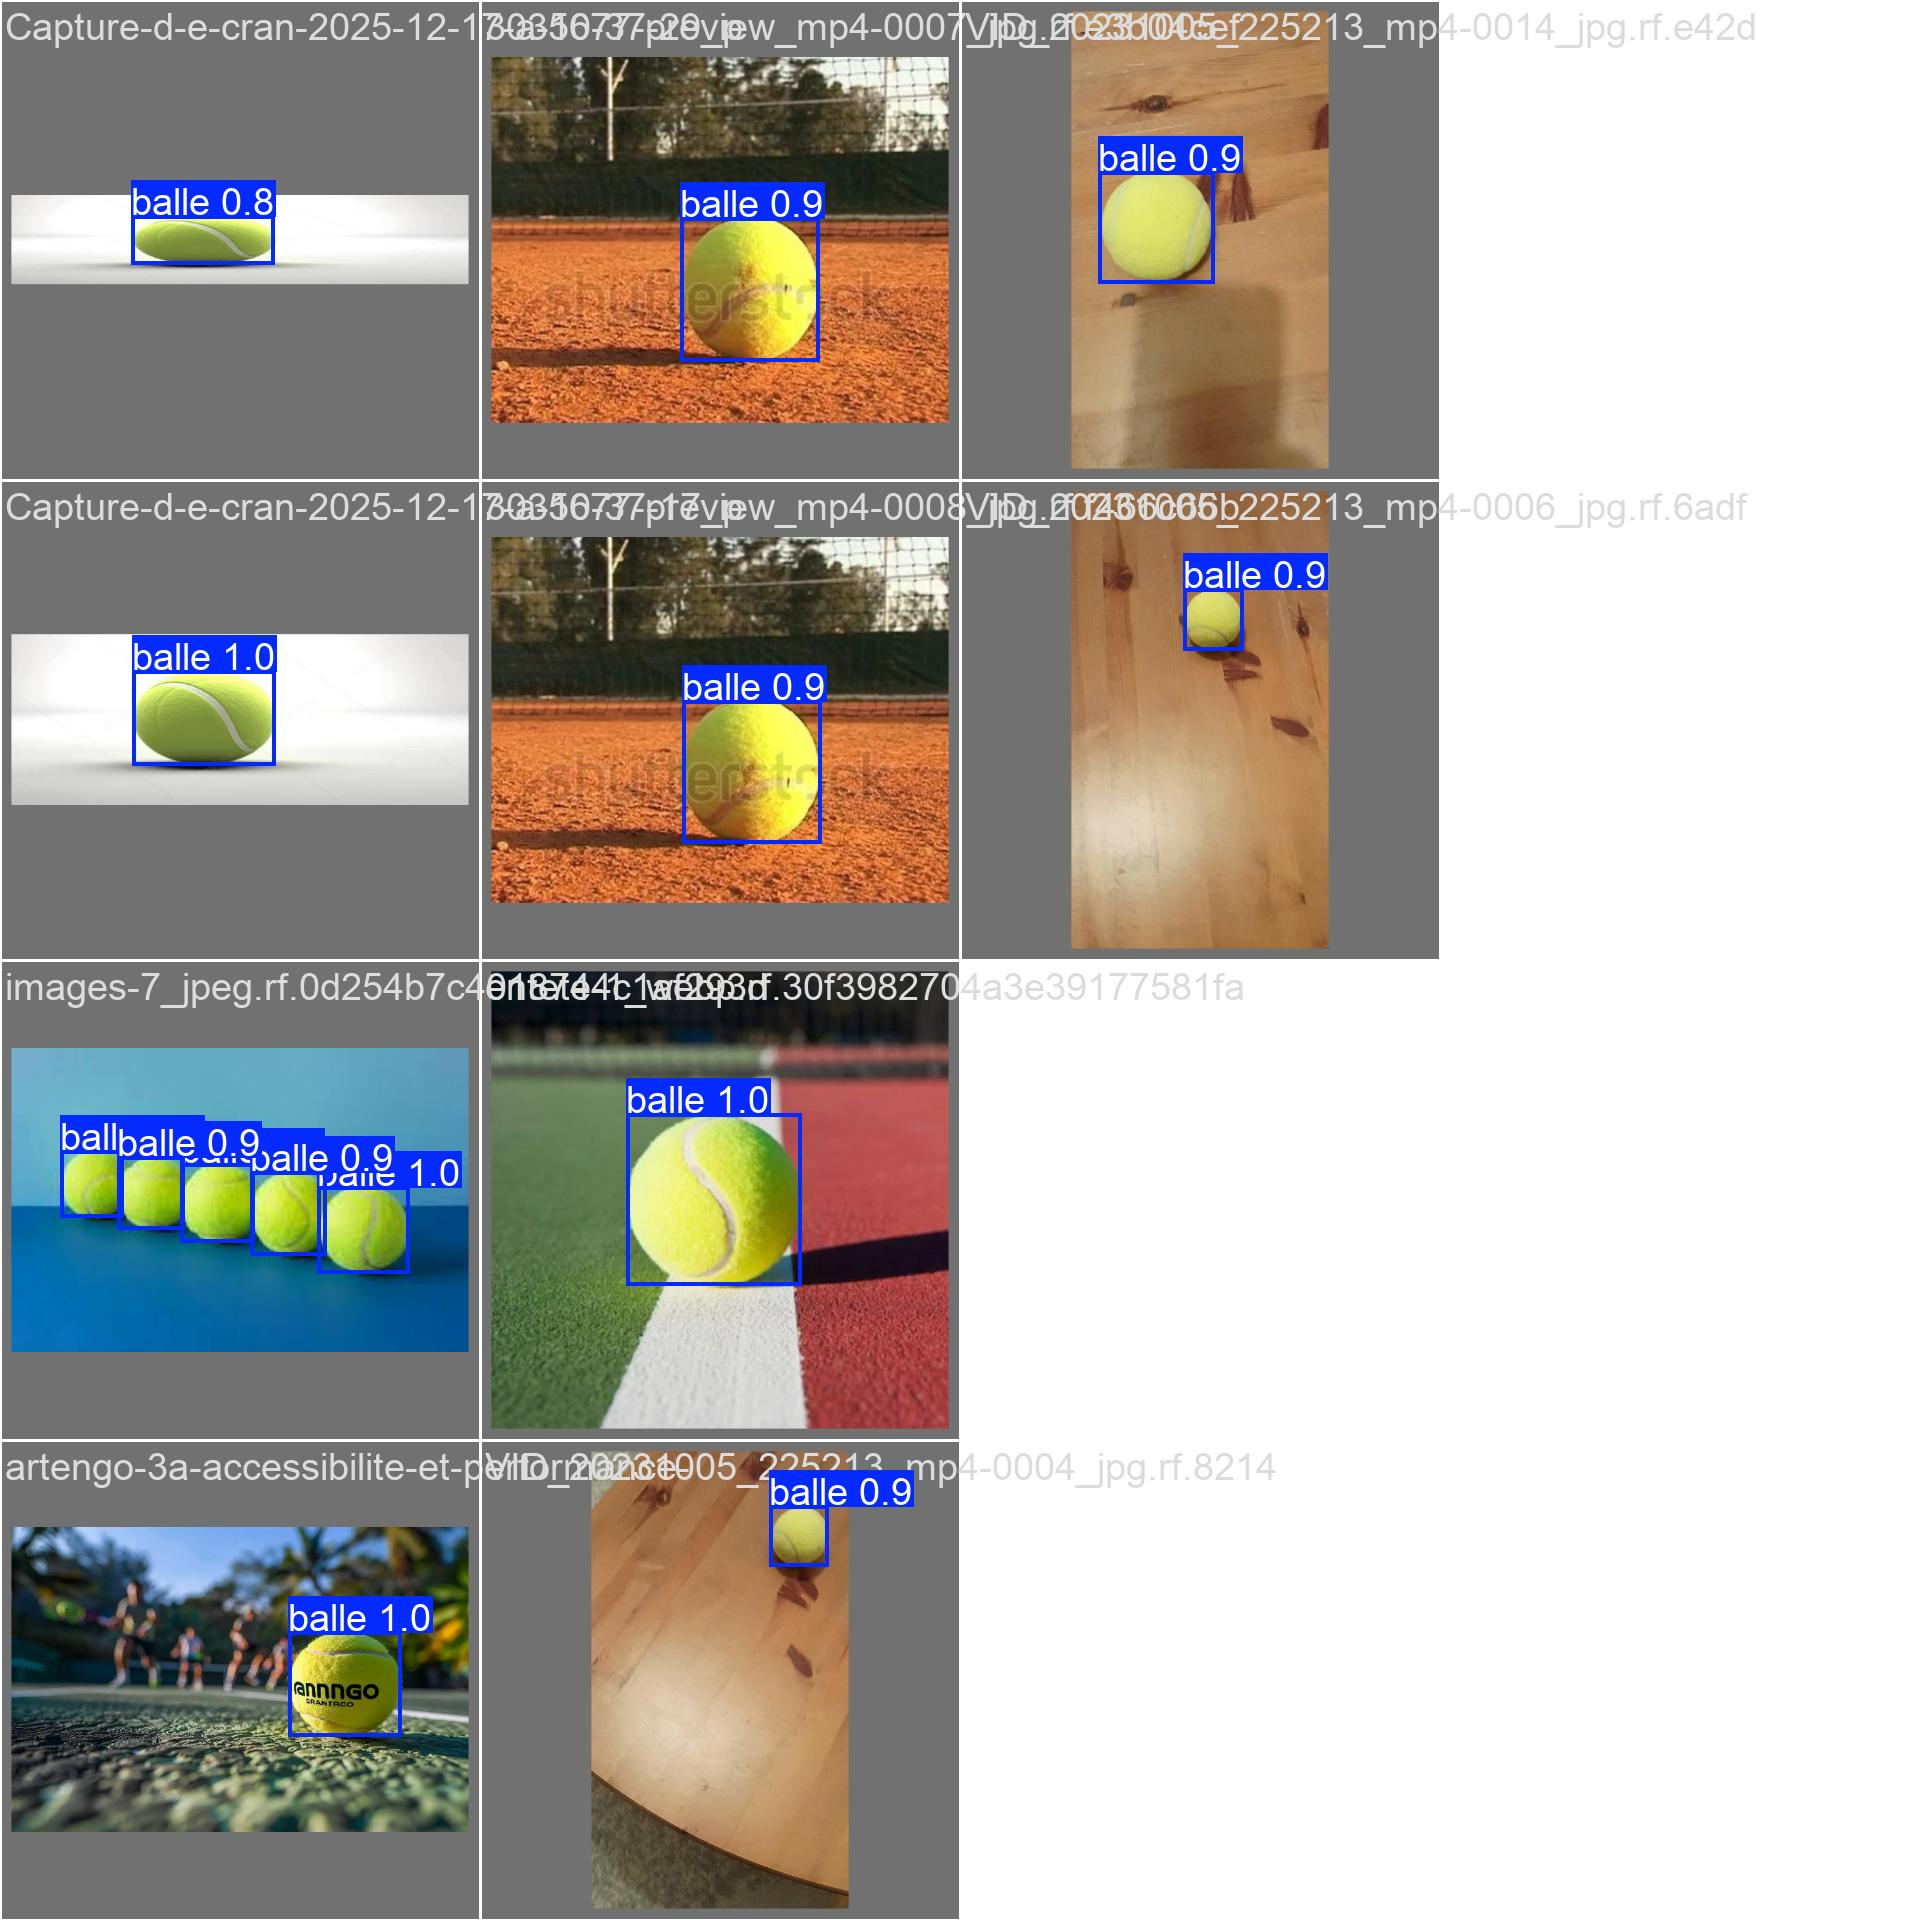


Gráficos de Treinamento:


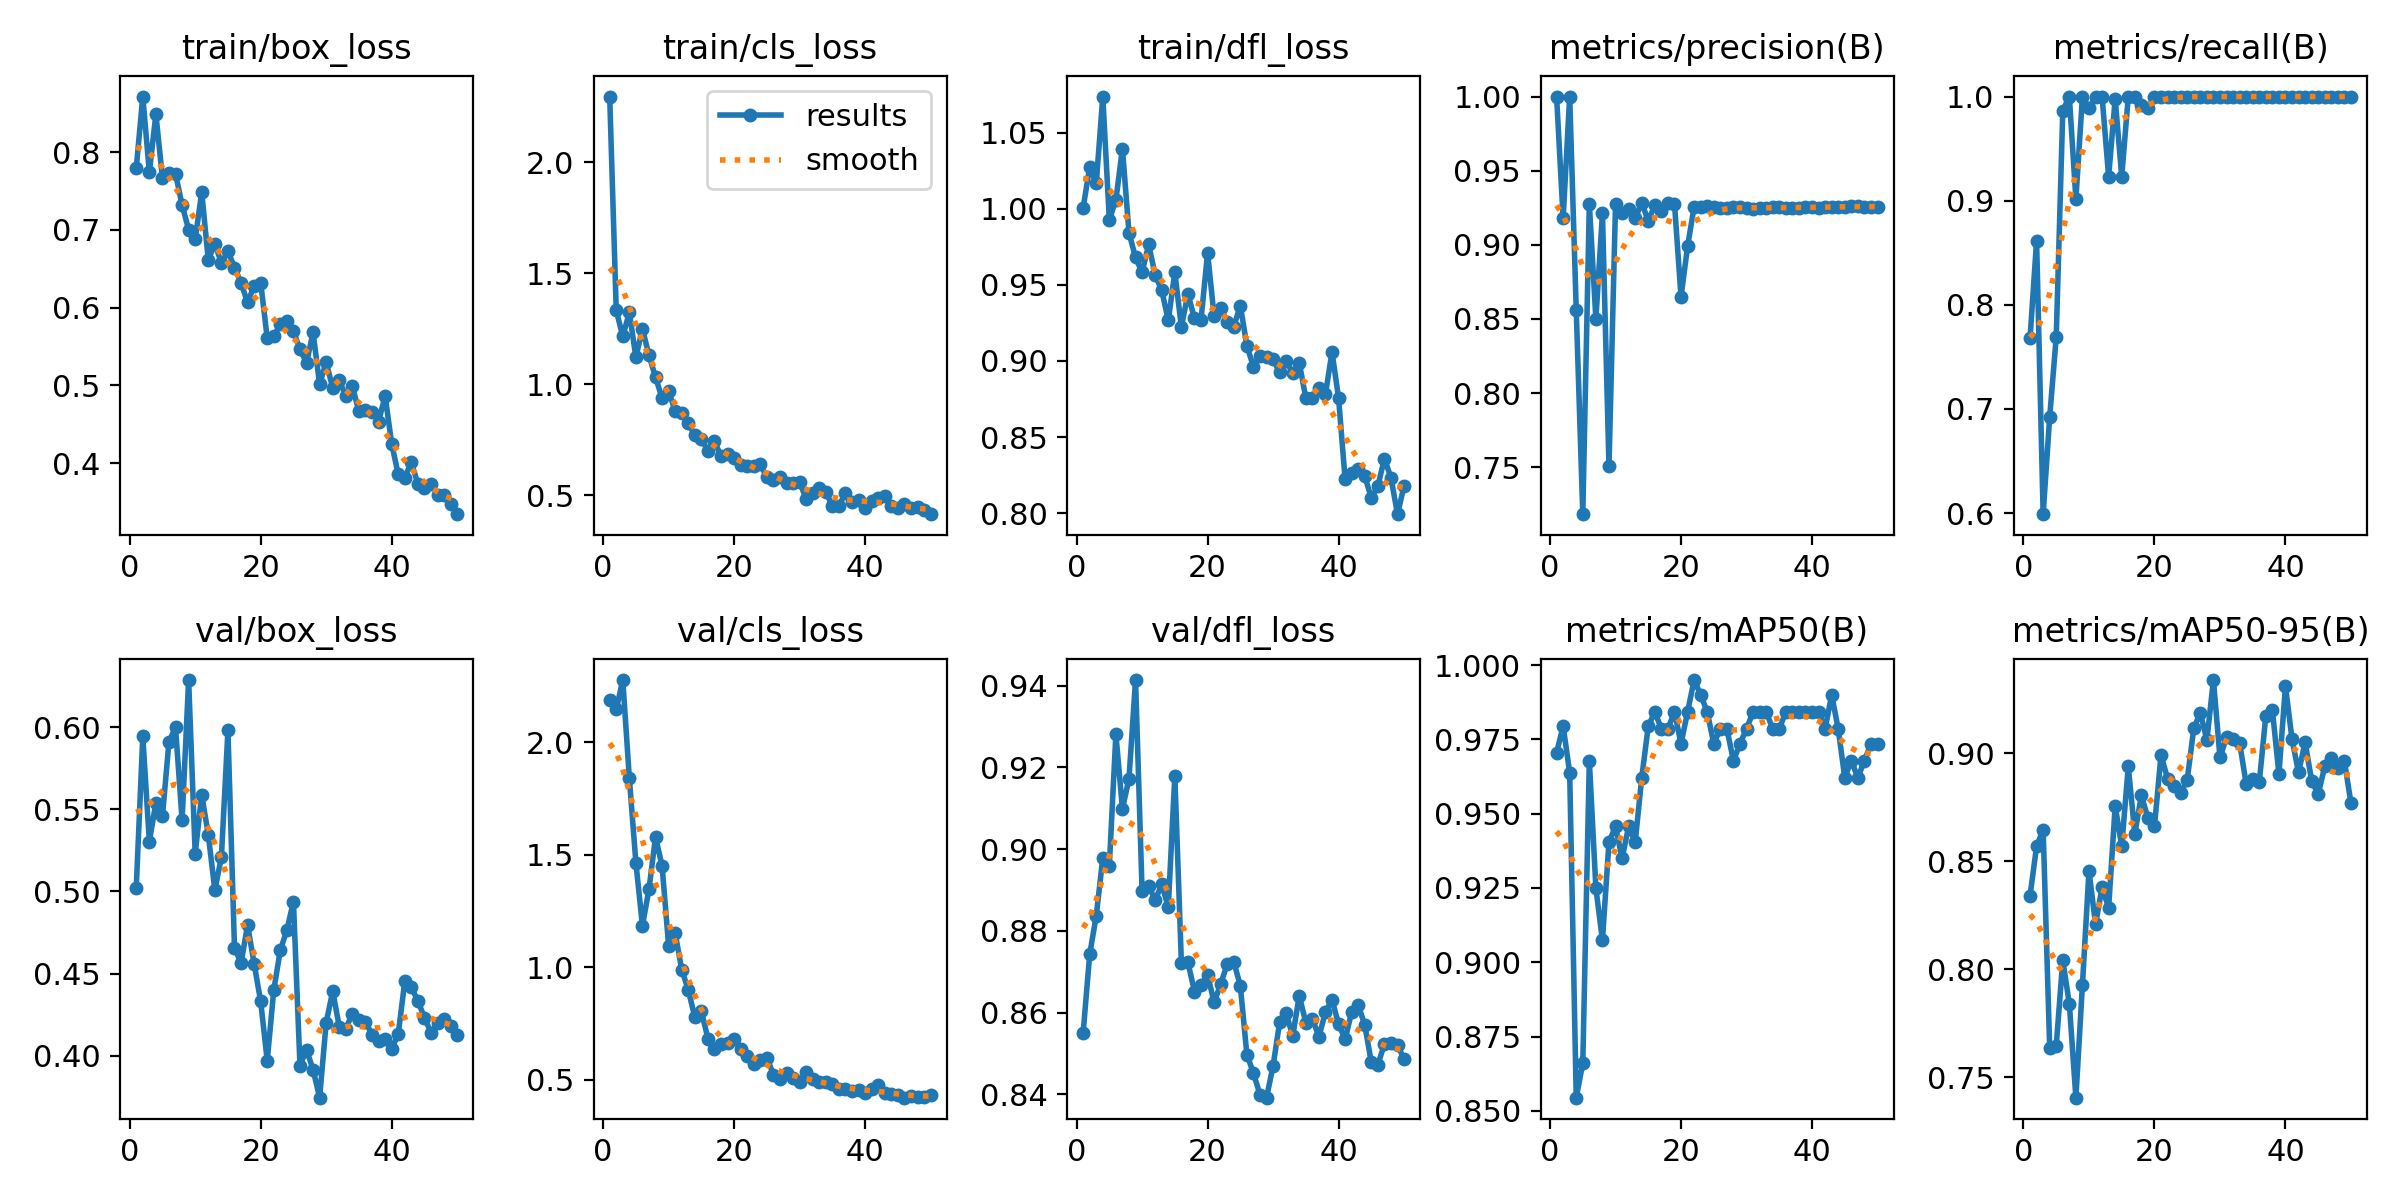

In [4]:
from IPython.display import Image, display
import glob

# Pegando a última pasta de treino criada:
list_of_runs = glob.glob('runs/detect/train*')
latest_run = max(list_of_runs, key=os.path.getctime) if list_of_runs else None

if latest_run:
    print(f"Analisando resultados da pasta: {latest_run}")
    
    # Mostrar as predições em um lote de validação
    val_img = os.path.join(latest_run, 'val_batch0_pred.jpg')
    if os.path.exists(val_img):
        print("Amostra de Validação:")
        display(Image(filename=val_img, width=800))
        
    # Mostrar o gráfico de resultados (loss, mapa)
    results_img = os.path.join(latest_run, 'results.png')
    if os.path.exists(results_img):
        print("\nGráficos de Treinamento:")
        display(Image(filename=results_img, width=800))
else:
    print("Nenhum resultado de treino encontrado ainda.")